# Previsão de Churn de Clientes — Modelo Preditivo

**Objetivo de negócio:** prever quais clientes de uma operadora de telecom têm maior probabilidade de cancelar o serviço (*churn*), para que a empresa possa agir de forma proativa (ofertas de retenção, contato do time de sucesso do cliente, etc.) antes que o cliente cancele.

**Dataset:** [Telco Customer Churn](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) (IBM) — 7.043 clientes, 21 colunas (dados demográficos, serviços contratados, forma de pagamento e se o cliente cancelou ou não).

**Estrutura deste notebook:**
1. Carregamento e limpeza dos dados
2. Análise exploratória (EDA)
3. Pré-processamento
4. Treino de modelos (Regressão Logística e Árvore de Decisão)
5. Avaliação e comparação
6. Interpretação e conclusões


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay
)

# Paleta acessível (colorblind-safe) e estilo consistente em todos os gráficos do notebook
sns.set_theme(style="whitegrid")
PALETA = sns.color_palette("colorblind")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1. Carregamento e limpeza dos dados

In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()


Linhas: 7043 | Colunas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` veio como texto (`object`) porque alguns clientes novos (tenure = 0) têm o campo em branco em vez de 0. Isso é um problema comum de qualidade de dados: valor ausente disfarçado de string vazia, não de `NaN` reconhecido pelo pandas.

In [4]:
# TotalCharges tem strings vazias — converter para numérico força esses casos a virarem NaN, que aí conseguimos tratar de verdade
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Valores nulos por coluna (apenas colunas com nulos):")
nulos = df.isnull().sum()
print(nulos[nulos > 0])


Valores nulos por coluna (apenas colunas com nulos):
TotalCharges    11
dtype: int64


In [5]:
# São 11 clientes com tenure = 0 (acabaram de entrar, ainda não fecharam um ciclo de cobrança) -> TotalCharges ausente faz sentido, não é erro de coleta.
# Preenchemos com 0, que é o valor real esperado para quem ainda não foi cobrado.
df.loc[df["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges"]]


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [6]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID é um identificador único, não carrega informação preditiva -> remover
df = df.drop(columns=["customerID"])

# Padronizar o alvo como binário (1 = cancelou, 0 = ficou)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df.isnull().sum().sum(), df.shape


(np.int64(0), (7043, 20))

## 2. Análise exploratória (EDA)

### 2.1 Estatísticas descritivas e distribuição do alvo

In [7]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


Taxa geral de churn: 26.5%


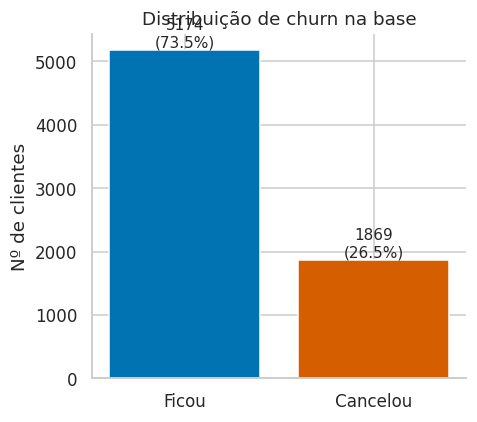

In [8]:
taxa_churn = df["Churn"].mean()
print(f"Taxa geral de churn: {taxa_churn:.1%}")

fig, ax = plt.subplots(figsize=(4.5, 4))
contagem = df["Churn"].value_counts().sort_index()
labels = ["Ficou", "Cancelou"]
ax.bar(labels, contagem.values, color=[PALETA[0], PALETA[3]])
for i, v in enumerate(contagem.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=10)
ax.set_title("Distribuição de churn na base")
ax.set_ylabel("Nº de clientes")
sns.despine()
plt.tight_layout()
plt.savefig("imagens/01_distribuicao_churn.png", bbox_inches="tight")
plt.show()


A base está desbalanceada (~26,5% de churn vs. ~73,5% que ficaram) — algo comum em problemas de churn. Isso importa na hora de avaliar o modelo: acurácia sozinha pode enganar (um modelo que sempre prevê "não cancela" já acertaria ~73%), por isso vamos olhar também precisão, recall e matriz de confusão.

### 2.2 Correlação entre variáveis numéricas

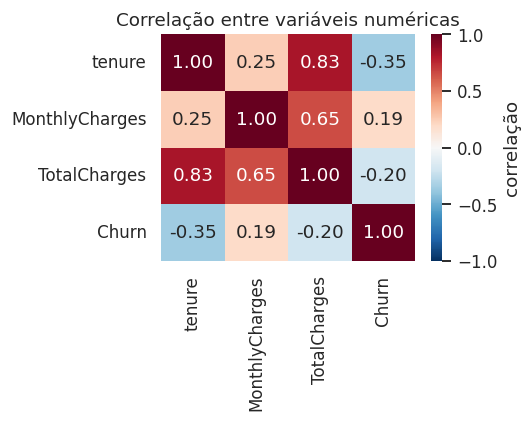

In [9]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={"label": "correlação"})
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.savefig("imagens/02_correlacao.png", bbox_inches="tight")
plt.show()


`tenure` (tempo de casa) tem a correlação mais forte com `Churn` (negativa: quanto mais tempo o cliente está na base, menor a chance de cancelar). `MonthlyCharges` tem correlação positiva fraca/moderada — mensalidades mais altas associam-se a mais cancelamento. `TotalCharges` correlaciona fortemente com `tenure` (é, no fundo, tenure × mensalidade acumulada), o que é esperado.

### 2.3 Outliers nas variáveis numéricas

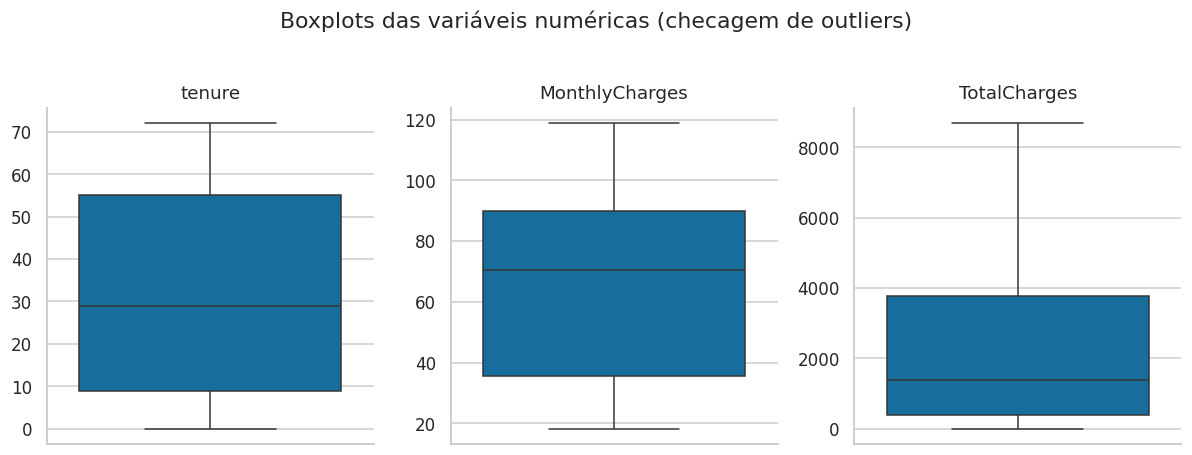

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(y=df[col], ax=ax, color=PALETA[0])
    ax.set_title(col)
    ax.set_ylabel("")
plt.suptitle("Boxplots das variáveis numéricas (checagem de outliers)", y=1.03)
sns.despine()
plt.tight_layout()
plt.savefig("imagens/03_outliers_boxplot.png", bbox_inches="tight")
plt.show()


Nenhuma das três variáveis mostra outliers extremos fora do esperado — os valores altos de `TotalCharges` são clientes antigos com mensalidade alta, o que é coerente com o negócio (não é erro de digitação nem valor impossível). Por isso, não há necessidade de remover pontos aqui.

### 2.4 Churn por variáveis categóricas relevantes

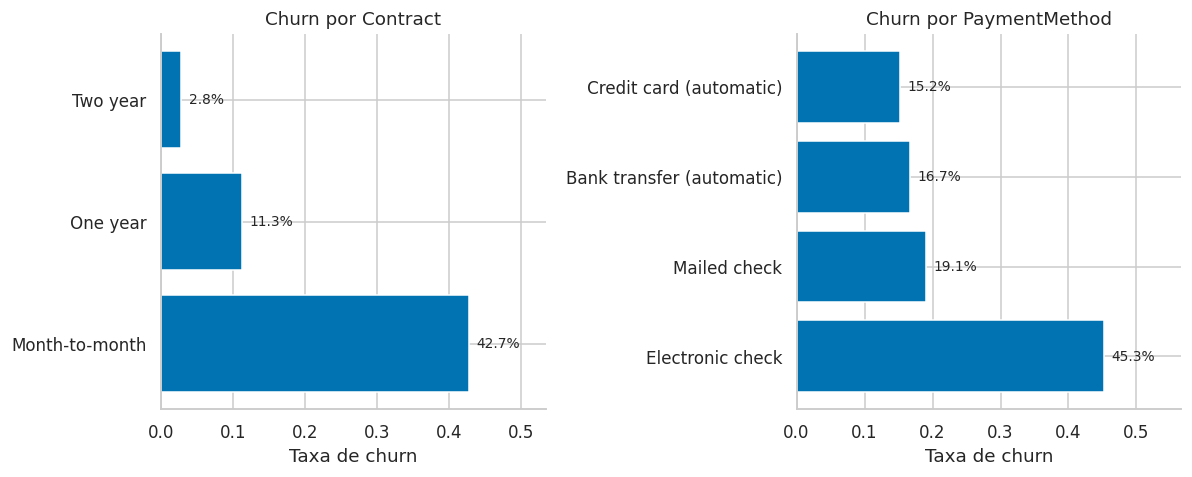

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col in zip(axes, ["Contract", "PaymentMethod"]):
    taxa = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    ax.barh(taxa.index, taxa.values, color=PALETA[0])
    for i, v in enumerate(taxa.values):
        ax.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=9)
    ax.set_xlim(0, taxa.max() * 1.25)
    ax.set_xlabel("Taxa de churn")
    ax.set_title(f"Churn por {col}")

sns.despine()
plt.tight_layout()
plt.savefig("imagens/04_churn_categoricas.png", bbox_inches="tight")
plt.show()


Dois sinais fortes pra EDA: contratos **mês a mês** têm taxa de cancelamento muito maior que contratos de 1 ou 2 anos, e clientes que pagam por **cheque eletrônico** cancelam bem mais que os demais métodos de pagamento. Esses dois padrões reaparecem no projeto de teste de hipótese, onde testamos formalmente se essa diferença é estatisticamente significativa ou pode ser coincidência.

## 3. Pré-processamento

In [12]:
# Variáveis categóricas -> one-hot encoding (drop_first evita multicolinearidade perfeita entre as dummies)
X = pd.get_dummies(df.drop(columns=["Churn"]), drop_first=True)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} clientes | Teste: {X_test.shape[0]} clientes")
print(f"Taxa de churn no treino: {y_train.mean():.1%} | no teste: {y_test.mean():.1%}")


Treino: 5282 clientes | Teste: 1761 clientes
Taxa de churn no treino: 26.5% | no teste: 26.5%


In [13]:
# Regressão Logística é sensível à escala das variáveis -> padronizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Treino dos modelos

Dois modelos simples e explicáveis, como pedido: **Regressão Logística** (modelo linear, coeficientes interpretáveis, ótimo baseline) e **Árvore de Decisão** (captura interações não-lineares, fácil de visualizar a lógica de decisão).

In [14]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]


In [15]:
# max_depth=4 mantém a árvore rasa o suficiente pra ser lida por um humano (evita overfitting e mantém a explicabilidade)
arvore = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE, class_weight="balanced")
arvore.fit(X_train, y_train)
y_pred_arv = arvore.predict(X_test)
y_proba_arv = arvore.predict_proba(X_test)[:, 1]


## 5. Avaliação e comparação dos modelos

In [16]:
def metricas(nome, y_true, y_pred, y_proba):
    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba),
    }

resultados = pd.DataFrame([
    metricas("Regressão Logística", y_test, y_pred_log, y_proba_log),
    metricas("Árvore de Decisão", y_test, y_pred_arv, y_proba_arv),
]).set_index("Modelo").round(3)

resultados


,Acurácia,Precisão,Recall,F1-score,ROC AUC
Modelo,,,,,
Regressão Logística,0.806,0.661,0.555,0.603,0.846
Árvore de Decisão,0.745,0.513,0.782,0.619,0.822


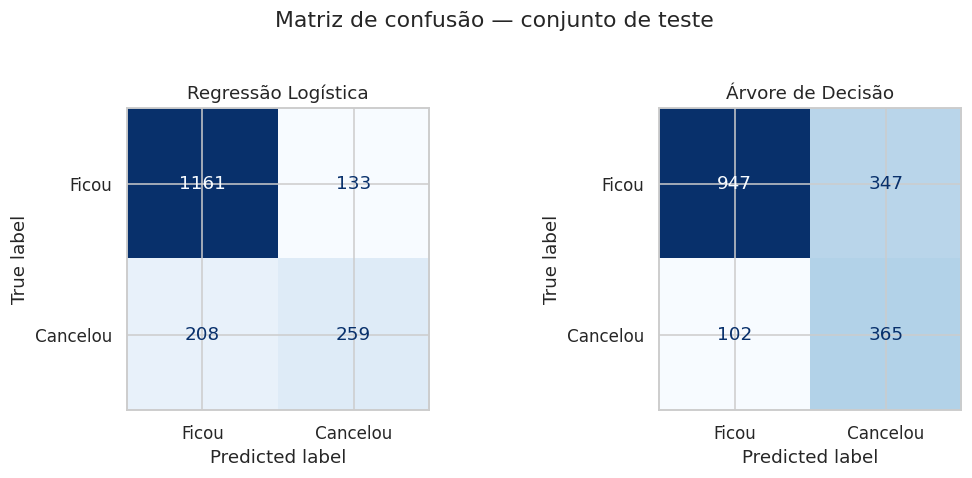

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

for ax, y_pred, nome in zip(axes, [y_pred_log, y_pred_arv], ["Regressão Logística", "Árvore de Decisão"]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Ficou", "Cancelou"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(nome)

plt.suptitle("Matriz de confusão — conjunto de teste", y=1.03)
plt.tight_layout()
plt.savefig("imagens/05_matrizes_confusao.png", bbox_inches="tight")
plt.show()


In [18]:
print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_log, target_names=["Ficou", "Cancelou"]))
print("\n=== Árvore de Decisão ===")
print(classification_report(y_test, y_pred_arv, target_names=["Ficou", "Cancelou"]))


=== Regressão Logística ===
              precision    recall  f1-score   support

       Ficou       0.85      0.90      0.87      1294
    Cancelou       0.66      0.55      0.60       467

    accuracy                           0.81      1761
   macro avg       0.75      0.73      0.74      1761
weighted avg       0.80      0.81      0.80      1761


=== Árvore de Decisão ===
              precision    recall  f1-score   support

       Ficou       0.90      0.73      0.81      1294
    Cancelou       0.51      0.78      0.62       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.75      0.76      1761



**Leitura das métricas:** recall na classe "Cancelou" é a mais importante pro negócio aqui — é o que mede quantos dos clientes que realmente iam cancelar o modelo conseguiu identificar a tempo. Errar prevendo que um cliente vai ficar (quando ele cancela) custa uma oportunidade de retenção perdida; errar prevendo cancelamento (quando ele ficaria) custa, no máximo, uma oferta de retenção desnecessária — os dois erros não têm o mesmo custo pro negócio, e por isso olhar só acurácia seria enganoso numa base desbalanceada como essa.

## 6. Interpretação dos modelos

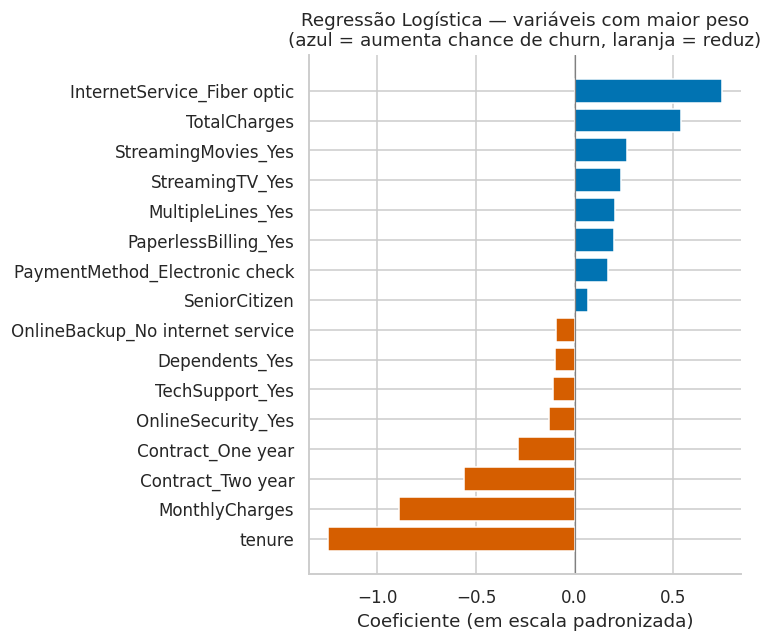

In [19]:
coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
top_coefs = pd.concat([coefs.head(8), coefs.tail(8)])

fig, ax = plt.subplots(figsize=(7, 6))
cores = [PALETA[3] if v < 0 else PALETA[0] for v in top_coefs.values]
ax.barh(top_coefs.index, top_coefs.values, color=cores)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Regressão Logística — variáveis com maior peso\n(azul = aumenta chance de churn, laranja = reduz)")
ax.set_xlabel("Coeficiente (em escala padronizada)")
sns.despine()
plt.tight_layout()
plt.savefig("imagens/06_coeficientes_logreg.png", bbox_inches="tight")
plt.show()


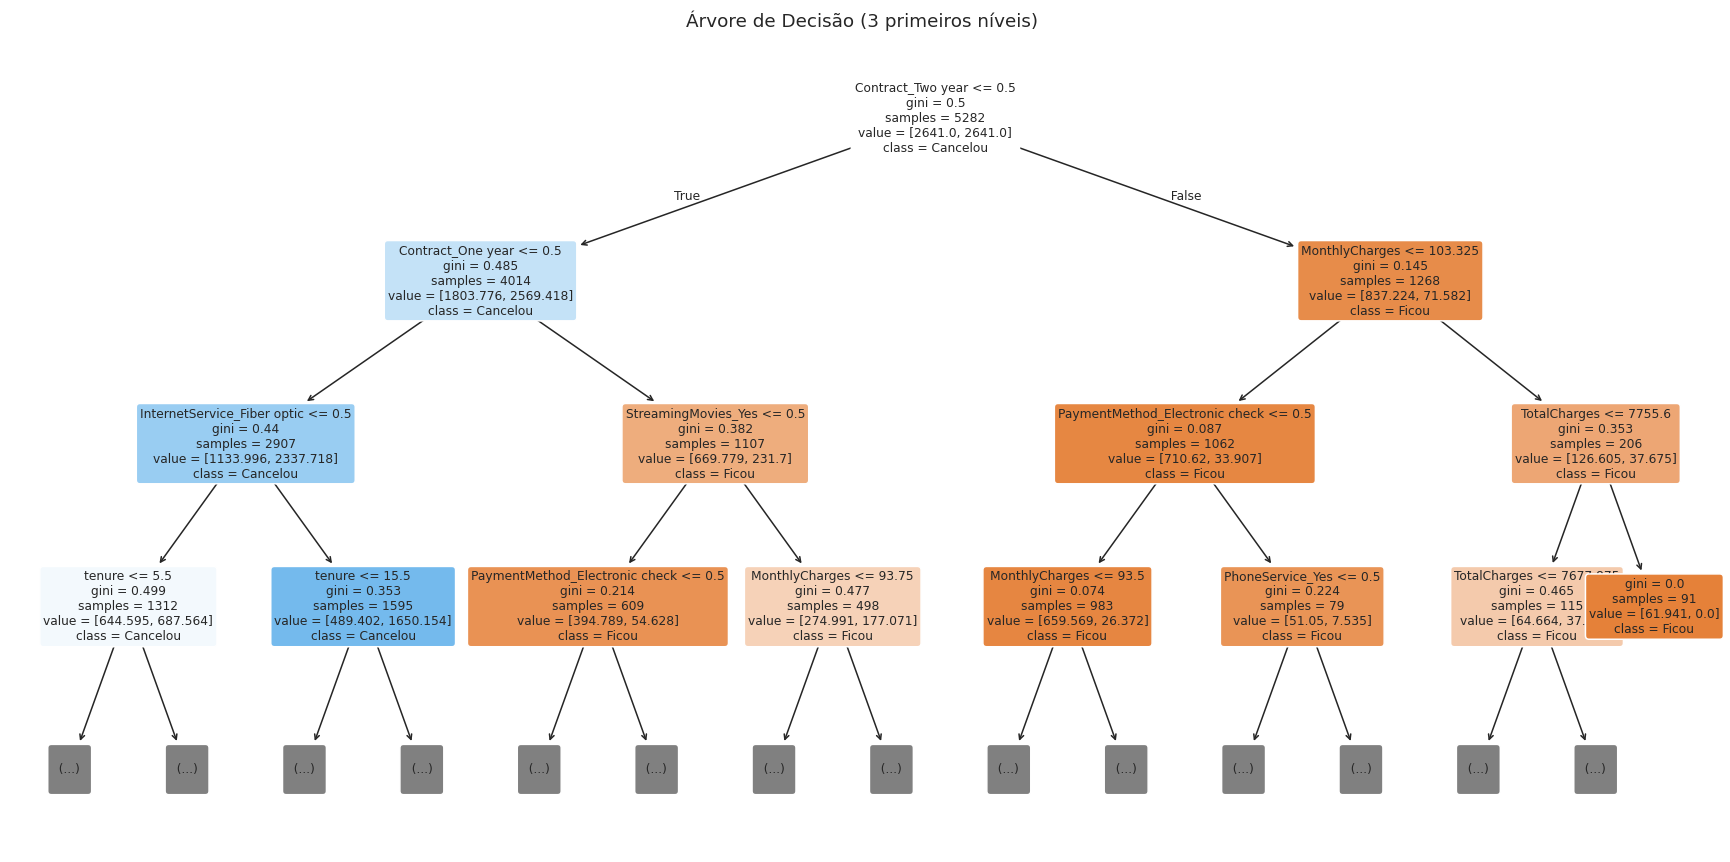

In [20]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    arvore, feature_names=X.columns, class_names=["Ficou", "Cancelou"],
    filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax
)
ax.set_title("Árvore de Decisão (3 primeiros níveis)")
plt.tight_layout()
plt.savefig("imagens/07_arvore_decisao.png", bbox_inches="tight")
plt.show()


**Principais fatores que aumentam a chance de churn**, segundo os dois modelos: contrato mês a mês, pagamento por cheque eletrônico, poucos meses de casa (`tenure` baixo), mensalidade alta e ausência de serviços adicionais (suporte técnico, segurança online). Isso confirma, agora com um modelo treinado e validado, os padrões que já tinham aparecido na EDA.

## 7. Conclusão e próximos passos

- Os dois modelos performam de forma parecida (ROC AUC ~0.82-0.84 nesse dataset), com a Regressão Logística levemente à frente — esperado, já que a relação entre as variáveis e o churn aqui é majoritariamente aditiva/linear.
- O modelo já é útil como está: pode gerar uma lista priorizada de clientes com alta probabilidade de churn (`predict_proba`) para o time de retenção agir.
- Próximos passos possíveis: balancear a base (SMOTE) para melhorar o recall, testar modelos mais robustos (Random Forest, XGBoost) e validação cruzada, e transformar isso num pipeline reprodutível (`sklearn.pipeline.Pipeline`) pronto para produção.
